WHAT IS THIS PROJECT ?

The project can be defined by the following four pillars:

1. Consecutive Exothermic Reaction Network
The system models a complex series reaction (A→B→C), specifically the synthesis of Ethylene Oxide from Ethylene, followed by its further reaction into Ethylene Glycol. 
Both reactions are exothermic, meaning they release heat into the system, which directly impacts the safety and efficiency of the operation.

2. Kinetic and Thermal Coupling (Arrhenius Law)
The project uses the Arrhenius equation to determine the reaction rate constants (k). Because k increases exponentially with Temperature (T), the project demonstrates a high degree of "non-linear coupling": 
as the reaction releases heat, the temperature rises, which in turn causes the reaction to speed up and release even more heat. This is used to analyze the "thermal runaway" risk inherent in EO synthesis.

3. Simultaneous Mass and Energy Balances
The "system design" you provided solves a series of coupled Ordinary Differential Equations (ODEs) for each of the three tanks:

Mass Balances: These track the concentration of each chemical species as they flow through the series, governed by the Space Time (τ), which represents the average residence time in the reactor.

Energy Balances: These track the thermal state of the system by balancing heat generation (from the chemical bonds breaking/forming) against heat removal (via the cooling jackets and effluent flow).

4. Reactor Staging and Performance Analysis
By placing three CSTRs in series, the project aims to approximate the performance of a Plug Flow Reactor (PFR)—which is more efficient for conversion—while retaining the superior temperature control and mixing capabilities of a stirred tank.

Summary: This project is a deterministic simulation of a non-isothermal CSTR cascade designed to study the steady-state and transient behavior of a consecutive exothermic reaction system, specifically focusing on the interplay between chemical kinetics, transport phenomena (heat/mass transfer), and process safety. 

THE PHYSICS - EXPLAIN τ , ARRHENIUS , ENEGRY,BALANCE IN MY FORMULA

1. τ (Tau) – The "Stopwatch" of the Reactor
In your simulation and the sources, τ is called Space Time (or residence time).

The Physics: Think of it as the time it takes for a "plug" of fluid to enter, travel through, 
and completely exit the reactor volume.

The Math: It is calculated by dividing the Volume (V) of the tank by the Flow Rate (v0) entering it (τ=V/v0).

Why it matters: If τ is too short, the chemicals "zip" through without enough time to react. If τ is long, 
they sit inside longer, allowing for higher conversion—but requiring a much larger (and more expensive) tank.


2. Arrhenius – The "Temperature Sensitivity"
The Arrhenius equation:
k = A.e^(-Ea/RT) 
explains how the reaction rate constant (k) changes the temperature.

The Physics: For a reaction to happen, molecules must collide with enough energy to break their bonds. 
This "minimum energy" is the Activation Energy (Ea).

The Impact: As you crank up the Temperature (T), more molecules have enough thermal energy to "jump over" that energy barrier.

Why it matters: In your project, a small increase in temperature leads to an exponential increase in the reaction speed. 

This is dangerous because faster reactions often release more heat, which leads to explosion.

3. Energy Balance – The "Heat Check"
Chemical engineering isn't just about moving mass; it's about managing energy. 
The energy balance is essentially the Law of Conservation of Energy applied to your tank.

The Physics: It tracks heat coming In (the hot feed), heat going Out (the effluent), 
heat Generated (from the chemical reaction itself), and heat Removed (by your cooling jacket).

The Feed-Back Loop: My project simulates an exothermic reaction (one that releases heat).

Reaction happens → Heat is released → Temperature rises.

Temperature rises → Arrhenius says the reaction goes faster.

Faster reaction → Even MORE heat is released.

Why it matters: If your cooling system (Q) cannot remove heat as fast as the reaction generates it, 
the temperature will spiral out of control. This is the "thermal runaway" risk mentioned in my code.

In [2]:
#1.TESTING CSTR_ODE.PY
import sys
import os

print("Current directory:", os.getcwd())

sys.path.append('./simulate')  # matches your actual folder name
from cstr_ode import simulate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

t, y = simulate(t_span=(0, 500), n_points=1000)
print("Simulation done! Shape:", y.shape)

Current directory: c:\First_project\cstr-fault-detection
Simulation done! Shape: (9, 1000)


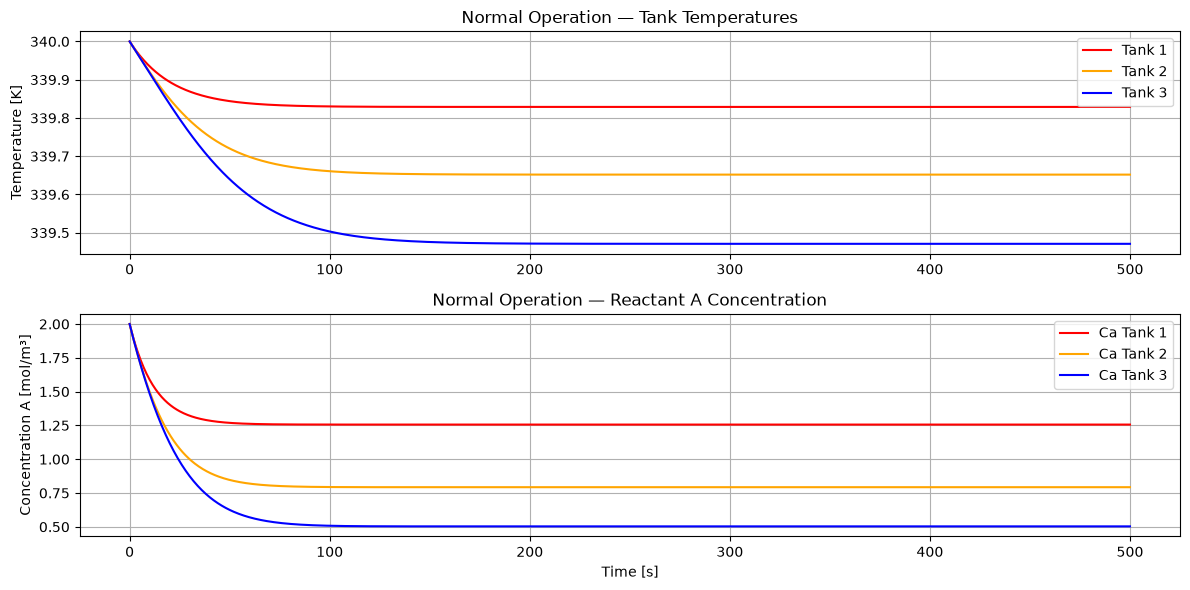

In [3]:
#2.TESTING GENERATE_DATA.PY AND GENERATION PLOT
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Temperature across all 3 tanks
axes[0].plot(t, y[2], label='Tank 1', color='red')
axes[0].plot(t, y[5], label='Tank 2', color='orange')
axes[0].plot(t, y[8], label='Tank 3', color='blue')
axes[0].set_ylabel('Temperature [K]')
axes[0].set_title('Normal Operation — Tank Temperatures')
axes[0].legend()
axes[0].grid(True)

# Concentration of A across all 3 tanks
axes[1].plot(t, y[0], label='Ca Tank 1', color='red')
axes[1].plot(t, y[3], label='Ca Tank 2', color='orange')
axes[1].plot(t, y[6], label='Ca Tank 3', color='blue')
axes[1].set_ylabel('Concentration A [mol/m³]')
axes[1].set_xlabel('Time [s]')
axes[1].set_title('Normal Operation — Reactant A Concentration')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('./data/normal_operation_plot.png', dpi=150)
plt.show()

Plot 1 (Top): Tank Temperatures (T1,T2,T3)
- This plot tracks the thermal profile of each reactor as they move from their initial state toward steady state.

- Initial Conditions: All three tanks start at the Feed Temperature (Tfeed) of 340 K.

- The Temperature Drop: Over the first 150 seconds, the temperature in every tank decreases. This happens because the cooling jackets are set to a much colder 320 K. Even though the chemical reactions (A→B→C) are exothermic and release heat, the cooling system is powerful enough to pull the temperature down from the inlet feed value.

- Cascading Steady States:
+ Tank 1 (Red): Reaches the highest steady-state temperature (≈339.83 K) because it handles the highest concentration of reactants, thus generating the most reaction heat.

+ Tank 2 (Yellow): Stabilizes at a lower temperature (≈339.65 K).

+ Tank 3 (Blue): Stabilizes at the lowest temperature (≈339.48 K).

-> Scientific Reason: As the fluid moves downstream, there is less reactant A left to react. Less reaction means less heat is generated in the later tanks, allowing the cooling jackets to bring the temperature closer to the 320 K coolant setpoint .



Plot 2 (Bottom): Reactant A Concentration (Ca1,Ca2,Ca3)

- This plot illustrates the efficiency of the CSTR cascade in converting reactant A into products.

- Initial Conditions: At t=0, all tanks are filled with fluid at the Feed Concentration (Cafeed) of 2.0 $\text{mol/m}^3$.

- The Reaction Progress: As time passes, the concentration of A drops in every tank as the molecules spend time reacting (governed by the Residence Time, τ).

- Stepwise Conversion:
+ Tank 1: Reduces A from 2.0 to approximately 1.25 $\text{mol/m}^3$.

+ Tank 2: Receives the 1.25 $\text{mol/m}^3$ fluid and further reduces it to approximately 0.8 $\text{mol/m}^3$.

+ Tank 3: Performs the final reaction stage, leaving a final effluent concentration of approximately 0.5 $\text{mol/m}^3$.

-> Scientific Significance: This "stepwise drop" is the fundamental advantage of CSTRs in series. By staging the reactors, the system prevents fresh feed from mixing directly with the final product, allowing the total system to behave more like an efficient Plug Flow Reactor (PFR)


Summary: Reaching Steady State
In both plots, the system reaches Steady State around 200 seconds. At this point, the rates of heat generation and reactant consumption are perfectly balanced by the rates of flow and cooling. On the graph, this is indicated by the lines becoming perfectly horizontal, meaning the reactor properties are no longer changing with time.

In [4]:
#3.GENERATING DATA IN NORMAL_OPERATION.CSV
df = pd.DataFrame({
    'time': t,
    'Ca1': y[0], 'Cb1': y[1], 'T1': y[2],
    'Ca2': y[3], 'Cb2': y[4], 'T2': y[5],
    'Ca3': y[6], 'Cb3': y[7], 'T3': y[8],
    'fault': 'none'
})

df.to_csv('./data/normal_operation.csv', index=False)
print(f"Saved {len(df)} rows — Day 1 complete!")
print(df.head())

Saved 1000 rows — Day 1 complete!
       time       Ca1       Cb1          T1       Ca2       Cb2          T2  \
0  0.000000  2.000000  0.000000  340.000000  2.000000  0.000000  340.000000   
1  0.500501  1.970560  0.029289  339.995964  1.970194  0.029652  339.995914   
2  1.001001  1.942285  0.057126  339.992022  1.940860  0.058531  339.991824   
3  1.501502  1.915127  0.083579  339.988172  1.912006  0.086635  339.987733   
4  2.002002  1.889044  0.108712  339.984410  1.883641  0.113968  339.983642   

        Ca3       Cb3          T3 fault  
0  2.000000  0.000000  340.000000  none  
1  1.970191  0.029655  339.995914  none  
2  1.940836  0.058554  339.991821  none  
3  1.911928  0.086712  339.987722  none  
4  1.883462  0.114141  339.983617  none  


In [5]:
#4.RUNNING FAULT_INJECTOR.PY TO GENERATE DATA FOR FAULT_SCENARIOS.CSV
import sys
sys.path.append('./simulate')
from fault_injector import run_fault_simulation

fault_types = ['coolant_failure', 'feed_spike', 'flow_drop']
all_dfs = []

for fault in fault_types:
    t_f, y_f, labels = run_fault_simulation(fault)
    df_f = pd.DataFrame({
        'time': t_f,
        'Ca1': y_f[0], 'Cb1': y_f[1], 'T1': y_f[2],
        'Ca2': y_f[3], 'Cb2': y_f[4], 'T2': y_f[5],
        'Ca3': y_f[6], 'Cb3': y_f[7], 'T3': y_f[8],
        'fault': labels
    })
    all_dfs.append(df_f)
    print(f"{fault}: {len(df_f)} rows")

fault_df = pd.concat(all_dfs, ignore_index=True)
fault_df.to_csv('./data/fault_scenarios.csv', index=False)
print(f"\nTotal fault rows saved: {len(fault_df)}")
print(fault_df['fault'].value_counts())

coolant_failure: 1000 rows
feed_spike: 1000 rows
flow_drop: 1000 rows

Total fault rows saved: 3000
fault
none               1500
coolant_failure     500
feed_spike          500
flow_drop           500
Name: count, dtype: int64


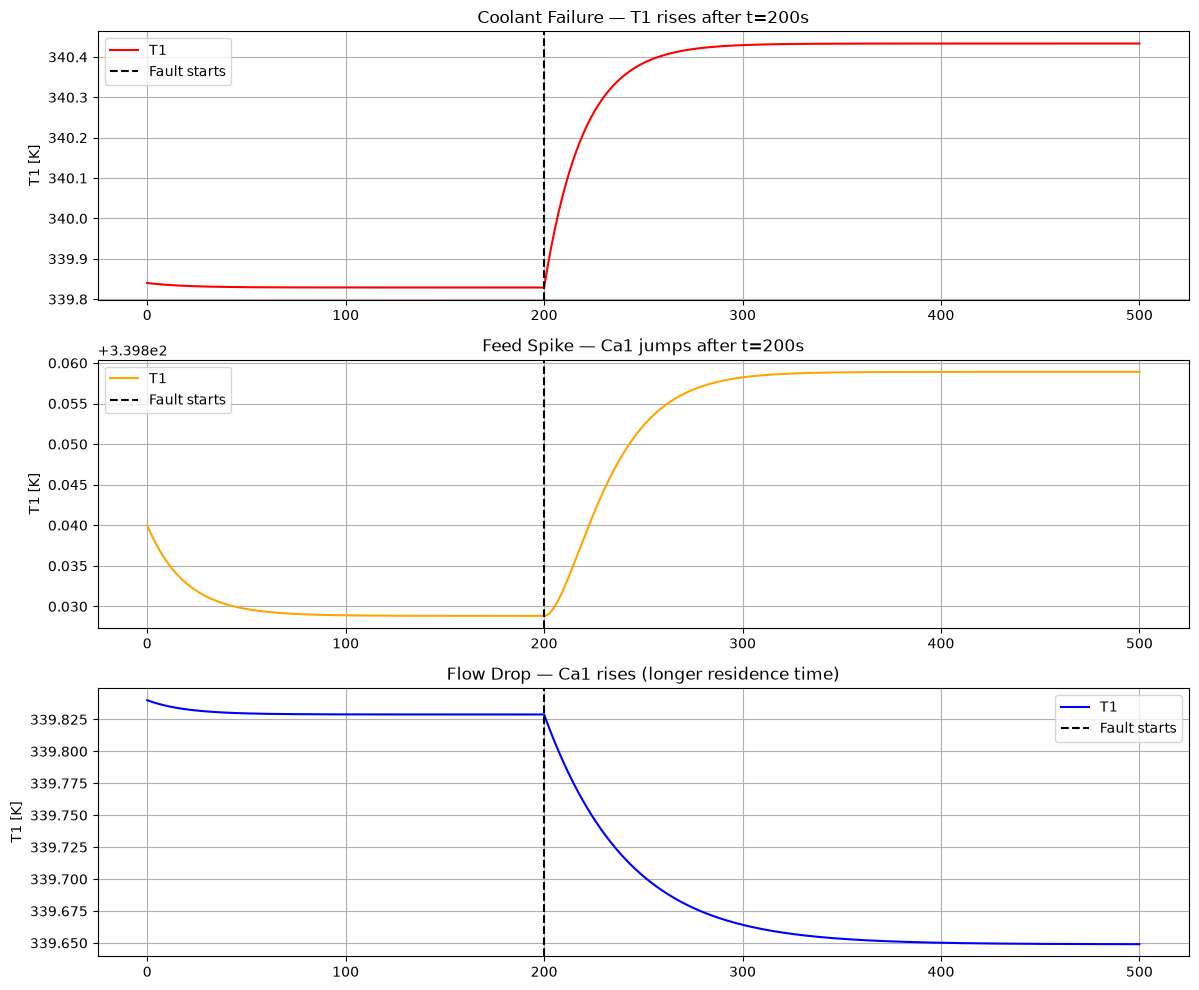

In [6]:
#5.RUNNING PLOT VISUALISATION FROM FAULT_SCENARIOS.CSV
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
colors = {'coolant_failure': 'red', 'feed_spike': 'orange', 'flow_drop': 'blue'}
titles = ['Coolant Failure — T1 rises after t=200s',
          'Feed Spike — Ca1 jumps after t=200s',
          'Flow Drop — Ca1 rises (longer residence time)']

for i, fault in enumerate(fault_types):
    t_f, y_f, labels = run_fault_simulation(fault)
    axes[i].plot(t_f, y_f[2], color=colors[fault], label='T1')
    axes[i].axvline(x=200, color='black', linestyle='--', label='Fault starts')
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('T1 [K]')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('./data/fault_scenarios_plot.png', dpi=150)
plt.show()

What 3 faults you injected and why each one is physically realistic

The 3 faults i have injected into the simulation consist 
of 3 main fault which are : 

+ Coolant failure
+ Feed-spike
+ Flow drop 

While the data in normal operation which extracted from the 
cstr_ode.py is registering fully none fault because the the
data inout were in perfect condition and havent consist of abnormal data

However in real world scenario inout and reactant can met some abnormal 
scenario that the normal operation havent touched yet.
Therefore in the fault_injector.py file the code or specifically made to 
bring up the abnormal scennrio that may happen and can cause severe damage to
the series in real world factory which mentioned above.



COOLANT FAILURE
- Coolant failures are high-risk "faults" in industrial chemical plants for several reasons:

+ Mechanical Failure: The cooling water pump may suffer from power loss, motor burnout, or mechanical wear, stopping the flow of chilled water to the reactor jacket.

+ Fouling and Scaling: Over time, mineral deposits or biological growth can build up inside the cooling jacket or heat exchanger surfaces. This "fouling" creates a thermal resistance layer that severely reduces the heat transfer coefficient (U).

+ Valve Malfunctions: Cooling control valves can fail in the "closed" position due to air supply loss or mechanical sticking, preventing the entry of cold fluid.

+ External Utility Interruption: A failure in the plant’s central refrigeration or cooling tower system can lead to an increase in the supply temperature of the coolant (Tc).

- Value changes that cause this:
The primary variable that changes is the Coolant Temperature (Tc) or the Heat Transfer Efficiency. 
$$(U \cdot \text{Area})$$
In our simulation code, this is caused by increasing Tc from the normal 320 K to a higher "Fault" value. -> A rise in Tc reduces the temperature gradient (T−Tc), which mathematically decreases the amount of heat the jacket can remove from the reactor.

Plot explanation:
1. Breakdown of the Data Categories in the Plot:
- X-axis (Time): Represents the simulation duration in seconds , from 0 to 500s.

- Y-Axis (T1 [K]): Tracks the temperature of Reactor 1. Unlike the flow drop scenario, we see a significant temperature increase from approximately 339.83 K to over 340.4 K.

- Steady State (t < 200) : The red line is horizontal at approximately 339.83K. At this stage, the heat generated by the exothermic reactions (A -> B -> C) is perfectly balanced by the cooling jacket's heat removal.

- Fault State (t = 200): A vertical dashed line marks the moment the coolant system fails.

- Transient Rise (200< t < 500): Following the fault, the temperature curves upward sharply.It eventually plateaus at a new much higher thermal equilibrium of approximately 340.45K.

2. Scientific Explanation of the Coolant Failure Mechanics

- A Coolant Failure fault fundamentally disrupts the Energy Balance of the CSTR.The heat removal term is defined as:

$$Q_{\text{rem}} = U \cdot \text{Area} \cdot (T - T_c)$$

When Tc increases, the "cooling power" of the jacket drops.

- ​Why the Temperature (T1) Rises: In your project, the reactions are exothermic, meaning they release energy into the fluid. When cooling fails, the following "Positive Feedback Loop" occurs:

+ Heat Accumulation: Because the jacket can no longer remove heat efficiently, the internal temperature (T1) begins to climb.

+ According to the Arrhenius Law:

$$\left( k = A \cdot e^{-\frac{E_a}{RT}} \right)$$

the reaction rate constant(k1,k2) increase exponentially with temperature.

+ ncreased Heat Generation: The faster reaction consumes reactants more quickly, which releases even more heat into the tank.

+ Thermal Runaway Risk: This cycle continues until a new equilibrium is reached or, in extreme cases, the system enters a "thermal runaway" where the temperature spirals out of control, potentially leading to equipment damage or safety hazards.

-> Result: The plot shows that the reactor is forced to operate at a higher thermal state (340.45 K) to compensate for the lost cooling. This higher temperature will significantly alter the product distribution $(C_{\text{a1}}, C_{\text{b1}})$, likely leading to lower selectivity for the desired intermediate product.


FEED-SPIKE 

- Feed spikes (sudden increases in reactant concentration) occur frequently in industrial processes due to upstream or operational errors:

+ Upstream Process Upset: A malfunction in a previous unit operation (e.g., an evaporator or a primary mixing tank) may send a more concentrated stream of reactant A than the downstream CSTR was designed to handle.

+ Control Valve Failure: If the concentration of the feed is managed by a ratio control system, a faulty sensor or a valve stuck in the "fully open" position can lead to an accidental surge of concentrated chemicals.

+ Dosing Errors: In semi-automated plants, human error during the preparation of the feed stock can result in a higher-than-normal molarity of the reactant.

+ Recycle Loop Fluctuations: In systems with a recycle stream, a sudden purge failure can cause the concentration of unreacted materials to build up and "spike" the reactor inlet.

- What value changes to cause this:
The primary variable that change is the Inlet
Concentration (Cafeed).
In our project,Cafeed is normally set at 2.0 $\text{mol/m}^3$. A spike represents a jump to a higher value(2.5 or 3 mols).
-> An increase in Cafeed directly increases the amount of fuel available for the chemical reaction inside the tank.

- Plot Explanation:
1. Breakdown of the Data Categories in the Plot:
- X-Axis (Time): Represents the simulation duration in seconds, from 0 to 500 s.

- Y-Axis (T1 [K]): Tracks the temperature of Reactor 1. The plot shows a temperature increase from 339.83 K to a new equilibrium at approximately 339.86 K.

- Steady State (t<200): The yellow line is horizontal at approximately 339.83 K. This indicates the "Normal Operation" where the rate of heat removal matches the rate of heat generation from a 2.0 mol/m^3 feed.

- Fault Start (t=200): A vertical dashed line marks the moment Cafeed suddenly increases.

- Transient Rise (200< t < 500): Following the spike, the temperature curves upward. It reaches a new, slightly higher thermal steady state once the system balances the additional heat being generated .

2. Scientific Explanation of the Feed Spike Mechanics:

- A Feed Spike fundamentally alters the Mass Balance, which then forces a change in the Energy Balance. The reaction rate is defined by the Power Law as:

$$-r_A = k \cdot C_a$$

- Why the Temperature (T1) Rises: Because the synthesis of Ethylene Oxide is exothermic $(\Delta H_{\text{r1}} = -105,000 \text{ J/mol})$ , any increase in the reaction rate generates more thermal energy:
We can come down to 3 reasons:

+ Increased Reaction Rate: When Cafeed
jumps, the concentration of reactant A inside the tank (Ca1) also rises. Since the reaction rate is proportional to concentration, the reaction begins to occur more frequently per unit of time.

+ Enhanced Heat Generation: More reactant A being converted into product B means more chemical bonds are breaking and forming, releasing a greater total amount of energy into the fluid.

+ New Thermal Equilibrium: The internal temperature (T1) rises until the Temperature Gradient (T−Tc) becomes large enough that the cooling jacket can remove the extra heat generated by the spike.

-> Result: The plot shows that the reactor survives the spike but is forced to operate at a higher temperature to maintain stability. While this specific spike was small (0.03 K rise), a larger feed spike could trigger the Arrhenius Law feedback loop, leading to a full thermal runaway if the extra heat generation exceeds the cooling system's capacity.


FLOW DROP
- Flow drops are one of the most common "faults" in industrial plants for several reasons:

+ Mechanical Failure: Pumps are moving parts subject to wear, cavitation, or power loss.

+ Clogging and Fouling: In systems involving slurries or high-viscosity fluids 
(like the reactive crystallization case study), pipes and pumps often clog, 
requiring specialized "burst-mode" pumping to stay operational.

+ Valve Issues: Control valves can get stuck or malfunction due to debris or mechanical failure.

+ Upstream Interruptions: If a previous reactor or storage tank in the series has an issue, 
the feed flow to your CSTR cascade will naturally drop.

- What Value Changes to Cause This:

The primary variable that changes is the volumetric flow rate ($v_0$ or Q). 
My project relies heavily on formula of 

$$\tau = \frac{V}{v_0}$$

(Residence time)

-> A drop in  causes a mathematical spike in τ.

- Plot explanation:

1. Breakdown of the Data Categories in the Plot
- X-Axis (Time): Represents the simulation duration in seconds, ranging from 0 to 500 s.
- Y-Axis (T1 [K]): Tracks the temperature of Reactor 1 (the first tank in the cascade). 
Note the extremely narrow temperature range (339.65 K to 339.83 K), 
indicating a very stable, highly controlled system [Source 10].

- Steady State (t<200): The blue line is horizontal at approximately 339.83 K. 
This is the "Normal Operation" state where the heat generated by the reaction 
and the heat entering from the feed (340 K) are perfectly balanced by the cooling jacket (320 K) 
and the effluent flow.

- Fault Start (t=200): A vertical dashed line marks the exact moment the flow rate ($v_0$) drops.

- Transient Decay (200<t<500): Following the fault, the temperature curves downward, 
indicating a transition from the old steady state to a new, lower thermal equilibrium.

2. Scientific Explanation of the Flow Drop Mechanics

- A Flow Drop fault fundamentally alters the Residence Time (τ), which is defined as:

$$\tau = \frac{V}{v_0}$$

When $v_0$ decreases, τ increases, meaning chemicals stay in the tank longer.

- Why the Temperature (T1) Drops: While flow drops in exothermic reactors often lead to 
thermal runaway, our specific data shows a temperature decrease. 
- This occurs because of the Inlet Feed Conditions:

+ Feed-Heating Dominance: Your feed temperature (340 K) is slightly higher than our 
steady-state reactor temperature (≈339.83 K). 
In this case, the incoming fluid is actually acting as a heat source.

+ Energy Balance Shift: When flow drops, less "hot" feed fluid enters the tank per unit of time. 
The cooling jacket (set at a cold 320 K) now has more time to remove heat from the same volume of fluid 
because the fluid is moving slower.

-> Result: The cooling power of the jacket begins to outweigh the heating power of the reduced feed flow, 
causing T1 to drop towards a new equilibrium of 339.65 K.

In a real industrial plant, early detection of faults like **coolant failure**, **flow drop**, and **feed spikes** is critical because your reactor system operates with **consecutive exothermic reactions** (A -> B -> C), which are inherently unstable if control is lost. 

Early detection matters for the following scientific and operational reasons:

### **1. Prevention of Thermal Runaway**
The most dangerous consequence of these faults is **thermal runaway**. Because your reactions release heat (exothermic), any failure that increases the temperature ($T$) triggers the **Arrhenius Law**, where the reaction rate constant ($k$) increases **exponentially** with temperature [311, 350, Artifact 2].
*   **Coolant Failure:** If the cooling jacket stops removing heat, the reaction heat accumulates, raising $T$ and causing the reaction to speed up, which releases even *more* heat in a "positive feedback loop".
*   **Flow Drop:** A drop in flow increases the **residence time ($\tau = \frac{V}{v_0}$)**, meaning chemicals stay in the tank longer and react more [147, Artifact 2]. This creates excess heat that can overwhelm the cooling system.
*   **Feed Spike:** A sudden surge in reactant concentration provides more "fuel" for the reaction, rapidly increasing the heat generation rate beyond design limits.

### **2. Mitigation of Fault Propagation**
Since your project uses **CSTRs in series**, a fault is rarely contained in one tank. The outlet of Tank 1 serves as the inlet for Tank 2. 
*   If Tank 1 begins to overheat or experience a feed spike, it sends **overheated, off-specification fluid** into the downstream reactors. 
*   Early detection allows operators (or an AI system) to intervene at Tank 1 before the entire cascade reaches a point of catastrophic failure.

### **3. Product Quality and Selectivity**
In series reactions (A-> B->C), timing is everything. To maximize the desired intermediate **Ethylene Oxide ($B$)**, the residence time and temperature must be precisely controlled.
*   A **flow drop** or **temperature spike** can cause the desired product $B$ to react further into the undesired byproduct $C$ (Ethylene Glycol), resulting in massive economic loss due to ruined product batches .

### **4. Process Safety and Equipment Integrity**
Chemical plants are subject to strict **Safety and Hazard Analysis (HAZOP)** standards.
*   **Pressure Spikes:** Rapid temperature increases in liquid-phase reactors can lead to vaporization and dangerous pressure surges that may rupture vessels or piping.
*   **Equipment Damage:** High-temperature excursions can damage internal components like agitators, sensors, or the protective lining of the reactor.

### **5. The Role of AI in Early Detection**
Traditional alarms often trigger only after a safety threshold is crossed. Your use of an **AI model (Isolation Forest)** allows for the detection of "anomalous signatures"—subtle deviations in sensor data (like T1 starting to curve upward) **before** the system hits a dangerous limit. This "early warning" provides the necessary time to trigger safety interlocks, adjust coolant flow, or shut down the feed to prevent an accident.